# Full Project Notebook: e-SNLI to EBR

This notebook implements the full analysis pipeline for comparing older human explanations, synthetic older LLM explanations, and newer human feedback text.


# Project Overview

In this opening section, we define the research question, the datasets, and the sequence of analysis steps used throughout the notebook.

This notebook studies whether human written explanations collected in the LLM era look more similar to LLM generated explanations than to older human explanations.

## Main Research Question

Can a detector trained to separate older human explanations from LLM generated explanations identify a shift toward more LLM like writing in a newer explanation dataset?

## Core Idea

We use an older dataset with human explanations as the baseline for pre LLM explanation style. We then generate synthetic LLM explanations for the same examples and train a classifier to distinguish the two. After that, we apply the classifier to a newer human explanation dataset and examine whether those explanations receive higher LLM likeness scores.

This does **not** prove that annotators definitely used LLMs. Instead, it tests whether newer human explanations show writing patterns that are more consistent with LLM generated text.

## Datasets Used

### Old baseline dataset
**e SNLI**

This dataset contains:
- premise
- hypothesis
- gold label
- human written explanation

We use e SNLI as the source of older human explanations.

### Newer target dataset
**EBR**

This dataset contains:
- question
- answer
- system
- feedback
- additional annotation fields

We use the **feedback** field as the newer human written explanation text.

## What We Are Trying to Show

We want to compare three groups of explanation text:

1. older human explanations from e SNLI  
2. synthetic LLM explanations generated from e SNLI examples  
3. newer human explanations from EBR  

If the EBR explanations receive detector scores that are closer to the synthetic LLM explanations than to the older human explanations, that would be evidence consistent with a shift toward more LLM like explanation style.

## High Level Steps

### Step 1
Load and clean e SNLI.

### Step 2
Sample a balanced subset of e SNLI examples and extract:
- premise
- hypothesis
- label
- one human explanation

### Step 3
Load one pre generated synthetic LLM explanation for each sampled e SNLI example using the same input and gold label.

### Step 4
Build a binary classification dataset:
- class 0 is older human explanations
- class 1 is synthetic LLM explanations

### Step 5
Train a main explanation style detector using TF IDF features and Logistic Regression.

### Step 6
Evaluate the detector on held out e SNLI based data.

### Step 7
Train simple control models using shallow style features such as:
- length
- punctuation
- repetition
- stopword ratio
- lexical diversity

### Step 8
Run a stricter length matched control.

### Step 9
Load EBR and treat the `feedback` field as the newer target explanation text.

### Step 10
Score EBR explanations and compare distributions across old human, old LLM, and new human text.


### Environment And Imports
This cell initializes the notebook environment and imports all core libraries required for dataset processing, modeling, controls, visualization, and export.

Step-by-step:
1. Load foundational Python utilities.
2. Load data-science and ML packages.
3. Prepare tools used throughout the full pipeline.


In [85]:


from __future__ import annotations

import json
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit



### Resolve e-SNLI Source Or Local Subsets
This cell resolves whether the notebook is inspecting the full Hugging Face e-SNLI source splits or the already saved local sampled subsets in `data/raw`.

Step-by-step:
1. Check whether local sampled subset CSV files already exist.
2. Load the full Hugging Face source dataset only when those subset files are missing.
3. Hand off to the next cell for either source-level or subset-level inspection.


In [86]:

project_root = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
raw_dir = project_root / 'data' / 'raw'
train_subset_path = raw_dir / 'esnli_subset.csv'
test_subset_path = raw_dir / 'esnli_test_subset.csv'

dataset = None
train = None
test = None

if train_subset_path.exists() and test_subset_path.exists():
    print('Found local sampled e-SNLI subset CSVs in data/raw; the notebook will inspect those subsets unless a rebuild is required.')
else:
    dataset = load_dataset("esnli", trust_remote_code=True)
    print('Loaded the full e-SNLI source dataset from Hugging Face because local sampled subset CSVs were missing.')


Found local sampled e-SNLI subset CSVs in data/raw; the notebook will inspect those subsets unless a rebuild is required.


### Inspect e-SNLI Source Splits Or Local Sampled Subsets
This cell converts the available e-SNLI data into pandas DataFrames and makes it explicit whether the notebook is inspecting the full source dataset or the saved sampled subsets.

Step-by-step:
1. Convert the available train and test data into tabular format.
2. Print row counts with explicit wording about source versus subset inspection.
3. Preview sample rows to validate schema.



In [87]:

if dataset is not None:
    train = pd.DataFrame(dataset['train'])
    test = pd.DataFrame(dataset['test'])
    print(f'Inspecting full Hugging Face e-SNLI source splits: train rows={len(train)}, test rows={len(test)}')
    test.head()
else:
    train = pd.read_csv(train_subset_path) if train_subset_path.exists() else None
    test = pd.read_csv(test_subset_path) if test_subset_path.exists() else None
    if train is not None and test is not None:
        print(f'Inspecting local sampled e-SNLI subsets: train rows={len(train)}, test rows={len(test)}')
        test.head()
    else:
        raise FileNotFoundError(
            'Could not find local e-SNLI subset CSVs and dataset was not loaded. '
            'Run the e-SNLI loading cell again.'
        )


Inspecting local sampled e-SNLI subsets: train rows=8000, test rows=8000


### Build Balanced e-SNLI Subsets
This cell creates balanced train and test subsets of e-SNLI and saves them to raw data for downstream modeling.

A key design choice here is that the notebook keeps the train subset and the held-out test subset separate so the main detector can be evaluated without train/test overlap.

Step-by-step:
1. Define balanced sampling by NLI label.
2. Build cleaned train and test explanation subsets.
3. Keep the saved train and test subsets separate for held-out evaluation.
4. Save subset CSV files for the old-human baseline data.


In [88]:
def _balanced_sample_by_label(df: pd.DataFrame, label_col: str, n: int, seed: int) -> pd.DataFrame:
    labels = sorted(df[label_col].dropna().astype(int).unique().tolist())
    if not labels or len(df) <= n:
        return df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)

    per_label = n // len(labels)
    remainder = n % len(labels)
    parts = []
    used_indices = set()

    for i, lbl in enumerate(labels):
        cur = df[df[label_col].astype(int) == lbl]
        take = min(len(cur), per_label + (1 if i < remainder else 0))
        if take > 0:
            sampled = cur.sample(n=take, random_state=seed + i)
            parts.append(sampled)
            used_indices.update(sampled.index.tolist())

    out = pd.concat(parts, ignore_index=False) if parts else df.iloc[:0].copy()

    if len(out) < n:
        remaining = df.drop(index=list(used_indices), errors='ignore')
        if len(remaining) > 0:
            add_n = min(n - len(out), len(remaining))
            add = remaining.sample(n=add_n, random_state=seed + 999)
            out = pd.concat([out, add], ignore_index=False)

    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


subset_size = 8000
project_root = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
raw_dir = project_root / 'data' / 'raw'
raw_dir.mkdir(parents=True, exist_ok=True)

train_out_path = raw_dir / 'esnli_subset.csv'          
test_out_path = raw_dir / 'esnli_test_subset.csv'
FORCE_REBUILD_SUBSETS = False

if train_out_path.exists() and test_out_path.exists() and not FORCE_REBUILD_SUBSETS:
    print('Existing e-SNLI subset files found. Skipping rebuild to preserve alignment with LLM CSV files.')
    print(f'Using: {train_out_path}')
    print(f'Using: {test_out_path}')
else:
    if train is None or test is None:
        dataset = load_dataset('esnli', trust_remote_code=True)
        train = pd.DataFrame(dataset['train'])
        test = pd.DataFrame(dataset['test'])
        print('Loaded e-SNLI from Hugging Face for subset rebuild.')

    exp_col_train = 'explanation_1' if 'explanation_1' in train.columns else 'explanation'
    exp_col_test = 'explanation_1' if 'explanation_1' in test.columns else 'explanation'

    train_clean = (
        train[['premise', 'hypothesis', 'label', exp_col_train]]
        .rename(columns={exp_col_train: 'explanation'})
        .dropna(subset=['premise', 'hypothesis', 'label', 'explanation'])
        .copy()
    )
    train_clean['label'] = train_clean['label'].astype(int)

    test_clean = (
        test[['premise', 'hypothesis', 'label', exp_col_test]]
        .rename(columns={exp_col_test: 'explanation'})
        .dropna(subset=['premise', 'hypothesis', 'label', 'explanation'])
        .copy()
    )
    test_clean['label'] = test_clean['label'].astype(int)

    train_subset = _balanced_sample_by_label(train_clean, 'label', min(subset_size, len(train_clean)), seed=42)
    test_subset = _balanced_sample_by_label(test_clean, 'label', min(subset_size, len(test_clean)), seed=42)

    train_subset.to_csv(train_out_path, index=False)
    test_subset.to_csv(test_out_path, index=False)

    print(f'Saved balanced train subset: {len(train_subset)} rows -> {train_out_path}')
    print(train_subset['label'].value_counts().sort_index().to_dict())
    print(f'Saved balanced test subset: {len(test_subset)} rows -> {test_out_path}')
    print(test_subset['label'].value_counts().sort_index().to_dict())

pd.read_csv(train_out_path).head()


Existing e-SNLI subset files found. Skipping rebuild to preserve alignment with LLM CSV files.
Using: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_subset.csv
Using: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_test_subset.csv


,premise,hypothesis,label,explanation
0,Two people standing next to a road looking off...,Two people are outside.,0,people standing next to a road looking off a h...
1,People up form their seats with two TVs hangin...,There are people watching TV,0,: People implies are people
2,A young boy climbing a tree in grassy hills.,A boy climbing a tree.,0,The boy is climbing a tree so he must be young.
3,A man in a black hat walks down the street.,The man is walking home.,1,We cannot know the destination to which the ma...
4,Five women in purple outfits wait outside.,the women are models,1,"anybody can wear an outfit, not just models"


### Load And Save EBR Dataset
This cell loads the EBR train and test splits and saves raw CSV files so the newer `feedback` text field is available as the target explanation signal.

Step-by-step:
1. Load the EBR train and test splits.
2. Inspect shapes and available fields, especially the `feedback` column.
3. Save train, test, and combined EBR feedback CSV files using the train and test splits only.


In [89]:
project_root = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
out_dir = project_root / 'data' / 'raw'
out_dir.mkdir(parents=True, exist_ok=True)

train_csv = out_dir / 'ebr_train.csv'
test_csv = out_dir / 'ebr_test.csv'
combined_csv = out_dir / 'ebr_feedback.csv'

DOWNLOAD_EBR_IF_MISSING = False  # set True only if you want this cell to fetch from Hugging Face

if train_csv.exists() and test_csv.exists() and combined_csv.exists():
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    print('Using existing local EBR CSV files; the `feedback` column will be treated as the target explanation text.')
    print(train_df.shape, test_df.shape)
    print(train_df.columns.tolist())
    print('EBR target text field for scoring:', 'feedback')
elif DOWNLOAD_EBR_IF_MISSING:
    train_df = load_dataset('wadhma/EBR', split='train').to_pandas()
    test_df = load_dataset('wadhma/EBR', split='test').to_pandas()

    print(train_df.shape, test_df.shape)
    print(train_df.columns.tolist())
    print('EBR target text field for scoring:', 'feedback')

    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)

    ebr_feedback = pd.concat(
        [train_df.assign(split='train'), test_df.assign(split='test')],
        ignore_index=True
    )
    ebr_feedback.to_csv(combined_csv, index=False)

    print('Saved:', train_csv)
    print('Saved:', test_csv)
    print('Saved:', combined_csv)
else:
    print('EBR CSV files not found locally.')
    print(f'Expected: {train_csv}, {test_csv}, {combined_csv}')
    print('Set DOWNLOAD_EBR_IF_MISSING=True if network access is available.')



Using existing local EBR CSV files; the `feedback` column will be treated as the target explanation text.
(7058, 13) (5592, 13)
['articleid', 'dataset', 'questionid', 'question', 'system', 'answer', 'annotationid', 'correct_label', 'complete_label', 'feedback', 'ebr_raw', 'ebr_num', 'workerid']
EBR target text field for scoring: feedback


### Define Project Configuration And Utility Features
This cell centralizes project paths and experiment settings, then defines reusable text-style feature helpers.

Step-by-step:
1. Set directories and experiment constants.
2. Define tokenization and shallow style-feature utilities.
3. Prepare common helpers used by training and controls.



In [90]:
@dataclass
class Config:
    project_root: Path = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
    data_raw_dir: Path = project_root / 'data' / 'raw'
    data_processed_dir: Path = project_root / 'data' / 'processed'
    outputs_dir: Path = project_root / 'outputs'
    models_dir: Path = outputs_dir / 'models'
    figures_dir: Path = outputs_dir / 'figures'
    reports_dir: Path = outputs_dir / 'reports'

    esnli_subset_size: int = 8000
    esnli_subset_csv: Path = data_raw_dir / 'esnli_subset.csv'
    esnli_test_subset_csv: Path = data_raw_dir / 'esnli_test_subset.csv'

    # Generated synthetic e-SNLI explanations
    esnli_llm_csv: Path = data_raw_dir / 'esnli_llm_explanations.csv'
    esnli_llm_train_csv: Path = data_raw_dir / 'esnli_llm_explanations_train.csv'
    esnli_llm_test_csv: Path = data_raw_dir / 'esnli_llm_explanations_test.csv'

    # EBR (LLM-era target)
    ebr_dataset_name: str = 'wadhma/EBR'
    ebr_target_csv: Path = data_raw_dir / 'ebr_feedback.csv'

    random_seed: int = 42
    tfidf_max_features: int = 30000
    llm_like_threshold: float = 0.8

CFG = Config()

for p in [
    CFG.data_raw_dir,
    CFG.data_processed_dir,
    CFG.outputs_dir,
    CFG.models_dir,
    CFG.figures_dir,
    CFG.reports_dir,
]:
    p.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}

_WORD_RE = re.compile(r'\b\w+\b')
STOPWORDS = {
    'a','an','and','are','as','at','be','by','for','from','has','he','in','is','it','its','of','on',
    'that','the','to','was','were','will','with','this','these','those','their','there','because',
    'but','or','if','then','than'
}

NLI_ARTIFACT_STOPWORDS = {
    'premise', 'hypothesis', 'claim', 'entailment', 'entails', 'entailed',
    'contradiction', 'contradicts', 'contradicted', 'neutral',
    'supports', 'supported', 'conflicts', 'conflict', 'states', 'statement'
}


def build_main_tfidf_vectorizer() -> TfidfVectorizer:
    return TfidfVectorizer(
        max_features=CFG.tfidf_max_features,
        ngram_range=(1, 2),
        lowercase=True,
        stop_words=sorted(NLI_ARTIFACT_STOPWORDS),
    )


def _pick_first_existing(columns: list[str], candidates: list[str]) -> Optional[str]:
    cols = set(columns)
    for c in candidates:
        if c in cols:
            return c
    return None


def _tokenize(text: str) -> list[str]:
    return _WORD_RE.findall(str(text).lower())


def token_count(text: str) -> int:
    return len(_tokenize(text))


def clean_explanation_text(text: str) -> str:
    text = str(text).strip()
    if not text:
        return ''

    leading_patterns = [
        r'(?im)^\s*(premise|hypothesis|claim|label|gold label)\s*:\s*',
        r'(?im)^\s*the\s+(premise|hypothesis|claim)\s*(states|says|reads)\s+that\s*',
        r'(?im)^\s*(according\s+to|based\s+on)\s+the\s+(premise|hypothesis)\s*[:, -]?\s*',
        r'(?im)^\s*(this|it)\s+is\s+(supported|contradicted|refuted|entailed|justified|consistent)\s+because\s*',
        r'(?im)^\s*the\s+premise\s+(supports|supported|contradicts|contradicted|entails|entailed|refutes|refuted)\s+the\s+hypothesis\s+because\s*',
        r'(?im)^\s*the\s+hypothesis\s+is\s+(supported|contradicted|refuted|entailed)\s+by\s+the\s+premise\s*[:,-]?\s*',
        r'(?im)^\s*the\s+premise\s+provides\s+related\s+context\s*\((.*?)\)\s*,\s*but\s+it\s+does\s+not\s+provide\s+enough\s+evidence\s+to\s+confirm\s+or\s+deny\s+that\s*',
        r'(?im)^\s*the\s+premise\s+provides\s+related\s+context\s*[:, -]?\s*',
        r'(?im)^\s*this\s+is\s+consistent\s+with\s+the\s+claim\s+that\s*',
        r'(?im)^\s*this\s+shows\s+that\s*',
        r'(?im)^\s*this\s+means\s+that\s*',
    ]

    changed = True
    while changed:
        changed = False
        for pattern in leading_patterns:
            updated = re.sub(pattern, '', text)
            if updated != text:
                text = updated.strip()
                changed = True

    sentence_patterns = [
        r'(?im)(?<=[.!?])\s*this\s+is\s+consistent\s+with\s+the\s+claim\s+that\s*',
        r'(?im)(?<=[.!?])\s*this\s+is\s+(supported|contradicted|refuted|entailed|justified)\s+because\s*',
        r'(?im)(?<=[.!?])\s*the\s+claim\s+that\s*',
        r'(?im)(?<=[.!?])\s*the\s+hypothesis\s+is\s+(supported|contradicted|refuted|entailed)\s+by\s+the\s+premise\s*[:,-]?\s*',
        r'(?im)(?<=[.!?])\s*the\s+premise\s+(supports|supported|contradicts|contradicted|entails|entailed|refutes|refuted)\s+the\s+hypothesis\s+because\s*',
    ]
    for pattern in sentence_patterns:
        text = re.sub(pattern, ' ', text)

    text = re.sub(r'(?im)^\s*(because|since|as)\s+(?:because|since|as)\b', r'\1', text)
    text = re.sub(r'(?im)^\s*(because|since|as)\s*[,:-]?\s*', '', text)
    text = re.sub(r'(?im)(?<=[.!?])\s*(because|since|as)\s*[,:-]?\s*', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip(' -:;,.')


def clean_explanation_series(texts: pd.Series) -> pd.Series:
    return texts.astype(str).fillna('').map(clean_explanation_text)


def style_feature_df(texts: pd.Series) -> pd.DataFrame:
    rows = []
    for txt in clean_explanation_series(texts):
        toks = _tokenize(txt)
        n = len(toks)
        uniq = len(set(toks))
        stop = sum(1 for t in toks if t in STOPWORDS)
        rows.append({
            'token_count': n,
            'char_count': len(txt),
            'punct_count': sum(ch in '.,!?:;' for ch in txt),
            'repeat_rate': 0.0 if n == 0 else 1.0 - (uniq / n),
            'stopword_ratio': 0.0 if n == 0 else stop / n,
            'lexical_diversity': 0.0 if n == 0 else uniq / n,
        })
    return pd.DataFrame(rows)



### Data Loaders For e-SNLI And EBR
This cell defines robust loaders to standardize e-SNLI subsets and EBR `feedback` text into a unified explanation-text format.

Step-by-step:
1. Normalize e-SNLI labels and columns.
2. Load balanced old-human subsets.
3. Normalize EBR `feedback` and metadata fields for target scoring using the train and test splits consistently across notebook paths.



In [91]:
def _normalize_label_value(v):
    if pd.isna(v):
        return np.nan

    s = str(v).strip().lower()
    if s in LABEL_MAP.values():
        inv = {name: idx for idx, name in LABEL_MAP.items()}
        return inv[s]

    try:
        return int(float(s))
    except Exception:
        return np.nan


def load_esnli_subset(
    n: int,
    seed: int,
    subset_csv: Optional[Path] = None,
    train_df: Optional[pd.DataFrame] = None,
) -> pd.DataFrame:
    if subset_csv is not None and Path(subset_csv).exists():
        df = pd.read_csv(subset_csv)
        source = f'CSV ({subset_csv})'
    elif train_df is not None and not train_df.empty:
        df = train_df.copy()
        source = 'existing `train` DataFrame in notebook memory'
    else:
        ds = load_dataset('esnli', trust_remote_code=True)
        df = ds['train'].to_pandas()
        source = 'Hugging Face e-SNLI train split'

    cols = df.columns.tolist()
    premise_col = _pick_first_existing(cols, ['premise', 'sentence1', 'premise_text'])
    hypo_col = _pick_first_existing(cols, ['hypothesis', 'sentence2', 'hypothesis_text'])
    label_col = _pick_first_existing(cols, ['label', 'gold_label', 'nli_label'])
    exp_col = _pick_first_existing(cols, ['explanation_1', 'explanation', 'sentence_explanation'])

    missing = []
    if premise_col is None:
        missing.append('premise')
    if hypo_col is None:
        missing.append('hypothesis')
    if label_col is None:
        missing.append('label')
    if exp_col is None:
        missing.append('explanation')
    if missing:
        raise ValueError(f'Missing required e-SNLI columns in {source}: {missing}. Found: {cols}')

    out = (
        df[[premise_col, hypo_col, label_col, exp_col]]
        .rename(columns={
            premise_col: 'premise',
            hypo_col: 'hypothesis',
            label_col: 'label',
            exp_col: 'explanation',
        })
        .dropna(subset=['premise', 'hypothesis', 'label', 'explanation'])
        .copy()
    )

    out['label'] = out['label'].map(_normalize_label_value)
    out = out.dropna(subset=['label']).copy()
    out['label'] = out['label'].astype(int)

    if len(out) > n:
        out = _balanced_sample_by_label(out, 'label', n=n, seed=seed)

    out = out.reset_index(drop=True)
    out['label_name'] = out['label'].map(lambda x: LABEL_MAP.get(int(x), str(x)))
    return out


def _normalize_ebr_frame(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    cols = [c.lower() for c in df.columns]
    cmap = {c.lower(): c for c in df.columns}

    feedback_col = _pick_first_existing(cols, ['feedback', 'explanation', 'rationale', 'justification'])
    if feedback_col is None:
        raise ValueError(f'Could not find feedback/explanation column in EBR split={split_name}. Found: {list(df.columns)}')

    question_col = _pick_first_existing(cols, ['question', 'prompt'])
    answer_col = _pick_first_existing(cols, ['answer', 'response'])
    system_col = _pick_first_existing(cols, ['system', 'model', 'model_name'])
    correct_label_col = _pick_first_existing(cols, ['correct_label'])
    complete_label_col = _pick_first_existing(cols, ['complete_label'])
    ebr_num_col = _pick_first_existing(cols, ['ebr_num', 'score'])

    # IMPORTANT: drop NaN before string conversion to avoid literal "nan" texts
    valid = df[cmap[feedback_col]].notna()
    out = pd.DataFrame({'explanation': df.loc[valid, cmap[feedback_col]].astype(str)})

    if question_col:
        out['question'] = df.loc[valid, cmap[question_col]].astype(str).values
    if answer_col:
        out['answer'] = df.loc[valid, cmap[answer_col]].astype(str).values
    if system_col:
        out['system'] = df.loc[valid, cmap[system_col]].astype(str).values
    if correct_label_col:
        out['correct_label'] = df.loc[valid, cmap[correct_label_col]].values
    if complete_label_col:
        out['complete_label'] = df.loc[valid, cmap[complete_label_col]].values
    if ebr_num_col:
        out['ebr_num'] = df.loc[valid, cmap[ebr_num_col]].values

    out['split'] = split_name
    out['target_text_field'] = 'feedback' if feedback_col == 'feedback' else feedback_col
    out['explanation'] = out['explanation'].str.strip()
    out = out[out['explanation'].str.len() > 0].reset_index(drop=True)
    return out


def load_ebr_human_feedback(dataset_name: str = 'wadhma/EBR', local_csv: Optional[Path] = None) -> pd.DataFrame:
    # This project treats EBR `feedback` as the newer human explanation signal to be scored.
    # For consistency with the earlier raw-data preparation step, this loader uses only the train and test splits.
    if local_csv is not None and Path(local_csv).exists():
        df = pd.read_csv(local_csv)
        out = _normalize_ebr_frame(df, split_name='local_csv')
        out['source'] = f'local_csv:{local_csv}'
        return out

    ds = load_dataset(dataset_name)
    frames = []
    for split_name in ['train', 'test']:
        if split_name in ds:
            cur = ds[split_name].to_pandas()
            cur = _normalize_ebr_frame(cur, split_name=split_name)
            frames.append(cur)

    if not frames:
        raise ValueError(f'No usable splits found in dataset: {dataset_name}')

    out = pd.concat(frames, ignore_index=True)
    out['source'] = f'hf_dataset:{dataset_name}'
    return out



### Synthetic LLM Explanations Provenance
In this short section, we document where the synthetic old-LLM explanations came from before using them in detector training.

The synthetic e-SNLI LLM explanations used in this project were generated with an OpenAI LLM in a prior step and saved to CSV files (`esnli_llm_explanations_train.csv`, `esnli_llm_explanations_test.csv`, and `esnli_llm_explanations.csv`).

Step-by-step:
1. Record the provenance of the synthetic explanation files.
2. Clarify that generation happened before this notebook stage.
3. Use the saved CSV files as fixed detector inputs in the next section.


### Load Synthetic Old-LLM Explanations
This cell aligns generated e-SNLI LLM explanation CSVs with old-human subsets for detector training.

Step-by-step:
1. Read the synthetic LLM explanation files.
2. Align by premise and hypothesis when possible.
3. Keep strict alignment in the main pipeline, while preserving helper support for row-order fallback only if it is explicitly needed elsewhere.


In [92]:
def load_llm_explanations_from_csv(
    old_human: pd.DataFrame,
    csv_path: Path,
    allow_row_fallback: bool = False,
    min_match_ratio: float = 0.99,
) -> pd.DataFrame:
    if not Path(csv_path).exists():
        raise FileNotFoundError(f'Missing {csv_path}.')

    df = pd.read_csv(csv_path)
    cols = df.columns.tolist()
    exp_col = _pick_first_existing(cols, ['explanation', 'llm_explanation', 'generated_explanation'])
    if exp_col is None:
        raise ValueError(f'Could not find explanation column in {csv_path}. Found: {cols}')

    premise_col = _pick_first_existing(cols, ['premise', 'sentence1', 'premise_text'])
    hypo_col = _pick_first_existing(cols, ['hypothesis', 'sentence2', 'hypothesis_text'])

    base = old_human[['premise', 'hypothesis', 'label', 'label_name']].copy().reset_index(drop=True)

    if premise_col and hypo_col:
        temp = (
            df[[premise_col, hypo_col, exp_col]]
            .rename(columns={premise_col: 'premise', hypo_col: 'hypothesis', exp_col: 'explanation'})
            .dropna(subset=['premise', 'hypothesis', 'explanation'])
        )
        temp = temp.drop_duplicates(subset=['premise', 'hypothesis'], keep='first')
        merged = base.merge(temp, on=['premise', 'hypothesis'], how='left')
        missing = int(merged['explanation'].isna().sum())
        match_ratio = 1.0 - (missing / max(len(base), 1))

        if missing == 0:
            return merged

        if allow_row_fallback and len(df) >= len(base):
            temp_row = df[[exp_col]].rename(columns={exp_col: 'explanation'}).dropna(subset=['explanation']).reset_index(drop=True)
            if len(temp_row) >= len(base):
                out = base.copy()
                out['explanation'] = temp_row['explanation'].astype(str).iloc[:len(base)].values
                print(
                    f'Warning: premise/hypothesis match ratio={match_ratio:.2%} (<{min_match_ratio:.0%}). '
                    'Using row-order fallback for LLM explanations. '
                    'This weakens paired-input validity.'
                )
                return out

        raise ValueError(
            f'Alignment failure for {csv_path}: match_ratio={match_ratio:.2%}, missing={missing}. '
            'Regenerate LLM explanations from the exact current e-SNLI subset or provide correctly aligned CSV files.'
        )

    temp = df[[exp_col]].rename(columns={exp_col: 'explanation'}).dropna(subset=['explanation']).reset_index(drop=True)
    if len(temp) < len(base):
        raise ValueError(
            f'Explanation row count mismatch for {csv_path}: got {len(temp)}, expected at least {len(base)}.'
        )

    if not allow_row_fallback:
        raise ValueError(
            f'{csv_path} lacks premise/hypothesis columns and strict alignment is enabled. '
            'Provide aligned premise/hypothesis columns or explicitly enable row fallback.'
        )

    out = base.copy()
    out['explanation'] = temp['explanation'].astype(str).iloc[:len(base)].values
    return out



### Train Main Detector And Control Models
In this section, we define the modeling functions used for the main detector and the control analyses.

Before training the main detector, we reduce prompt-style artifacts in two lightweight steps:
1. Apply targeted text cleanup to remove obvious synthetic NLI wrappers and canned lead-in phrases from explanations.
2. Suppress a narrow set of residual NLI scaffold tokens at the TF-IDF feature level, such as `premise`, `hypothesis`, `claim`, `supported`, `contradicts`, and related structural terms.

The goal is to make the detector rely less on synthetic prompt phrasing and more on broader explanation style, while keeping the overall project design unchanged.

Step-by-step:
1. Train and evaluate the main explanation-style detector with artifact-suppressed TF-IDF features.
2. Train and evaluate the style-only and length-matched controls.
3. Score groups, summarize distributions, and prepare audit and pattern-review tools.


In [93]:
def _require_eval_splits(old_human_eval, old_llm_eval):
    if old_human_eval is None or old_llm_eval is None:
        raise ValueError(
            'Held-out eval splits are required for reproducible evaluation. '
            'Provide both e-SNLI test human and test LLM CSV files.'
        )




def _check_min_class_counts(human_df: pd.DataFrame, llm_df: pd.DataFrame, stage: str, min_per_class: int = 25) -> None:
    c0 = int(len(human_df))
    c1 = int(len(llm_df))
    if c0 < min_per_class or c1 < min_per_class:
        raise ValueError(
            f'Length-matched {stage} has insufficient per-class counts: '
            f'class0={c0}, class1={c1}, required>={min_per_class}. '
            'Adjust the matching bins or increase subset size.'
        )


def _clean_binary_frames(old_human_df: pd.DataFrame, old_llm_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    human_df = old_human_df.copy()
    llm_df = old_llm_df.copy()
    human_df['explanation_clean'] = clean_explanation_series(human_df['explanation'])
    llm_df['explanation_clean'] = clean_explanation_series(llm_df['explanation'])
    human_df = human_df[human_df['explanation_clean'].str.len() > 0].reset_index(drop=True)
    llm_df = llm_df[llm_df['explanation_clean'].str.len() > 0].reset_index(drop=True)
    return human_df, llm_df


def _length_bin(length: int, width: int = 5, cap: int = 40) -> str:
    if length <= 0:
        return '00-00'
    if length > cap:
        return f'{cap + 1:02d}+'
    lower = ((length - 1) // width) * width + 1
    upper = min(lower + width - 1, cap)
    return f'{lower:02d}-{upper:02d}'


def _attach_length_bins(df: pd.DataFrame, width: int = 5, cap: int = 40) -> pd.DataFrame:
    out = df.copy()
    out['token_count'] = out['explanation_clean'].map(token_count)
    out['length_bin'] = out['token_count'].map(lambda n: _length_bin(int(n), width=width, cap=cap))
    return out


def _match_length_distributions(human_df: pd.DataFrame, llm_df: pd.DataFrame, stage: str, seed: int, width: int = 5, cap: int = 40) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    human_binned = _attach_length_bins(human_df, width=width, cap=cap)
    llm_binned = _attach_length_bins(llm_df, width=width, cap=cap)
    matched_human_parts = []
    matched_llm_parts = []
    matched_bins = []
    all_bins = sorted(set(human_binned['length_bin']).union(set(llm_binned['length_bin'])))
    for i, bin_name in enumerate(all_bins):
        human_bin = human_binned[human_binned['length_bin'] == bin_name]
        llm_bin = llm_binned[llm_binned['length_bin'] == bin_name]
        matched_n = min(len(human_bin), len(llm_bin))
        if matched_n == 0:
            continue
        matched_human_parts.append(human_bin.sample(n=matched_n, random_state=seed + i))
        matched_llm_parts.append(llm_bin.sample(n=matched_n, random_state=seed + 1000 + i))
        matched_bins.append(bin_name)
    if not matched_human_parts or not matched_llm_parts:
        raise ValueError(f'No matched length bins were available for stage={stage}.')
    human_matched = pd.concat(matched_human_parts, ignore_index=True)
    llm_matched = pd.concat(matched_llm_parts, ignore_index=True)
    _check_min_class_counts(human_matched, llm_matched, stage=stage)
    summary = {
        'matching_method': 'token_length_binned_subsample',
        'bin_width': width,
        'length_cap': cap,
        'matched_bins': matched_bins,
        'human_count_before': int(len(human_binned)),
        'llm_count_before': int(len(llm_binned)),
        'human_count_after': int(len(human_matched)),
        'llm_count_after': int(len(llm_matched)),
        'human_mean_length_before': float(human_binned['token_count'].mean()),
        'llm_mean_length_before': float(llm_binned['token_count'].mean()),
        'human_mean_length_after': float(human_matched['token_count'].mean()),
        'llm_mean_length_after': float(llm_matched['token_count'].mean()),
    }
    return human_matched.reset_index(drop=True), llm_matched.reset_index(drop=True), summary


def train_detector(
    old_human_train: pd.DataFrame,
    old_llm_train: pd.DataFrame,
    old_human_eval: Optional[pd.DataFrame] = None,
    old_llm_eval: Optional[pd.DataFrame] = None,
):
    _require_eval_splits(old_human_eval, old_llm_eval)
    human_train_clean, llm_train_clean = _clean_binary_frames(old_human_train, old_llm_train)
    human_eval_clean, llm_eval_clean = _clean_binary_frames(old_human_eval, old_llm_eval)
    train_df = pd.concat([
        human_train_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=0),
        llm_train_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=1),
    ], ignore_index=True)
    vectorizer = build_main_tfidf_vectorizer()
    Xtr = vectorizer.fit_transform(train_df['explanation'])
    ytr = train_df['y'].values
    clf = LogisticRegression(max_iter=2000, random_state=CFG.random_seed)
    clf.fit(Xtr, ytr)
    eval_df = pd.concat([
        human_eval_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=0),
        llm_eval_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=1),
    ], ignore_index=True)
    Xte = vectorizer.transform(eval_df['explanation'])
    yte = eval_df['y'].values
    p_test = clf.predict_proba(Xte)[:, 1]
    y_pred = (p_test >= 0.5).astype(int)
    metrics = {
        'f1': float(f1_score(yte, y_pred)),
        'auroc': float(roc_auc_score(yte, p_test)),
    }
    return vectorizer, clf, metrics


def train_style_only_detector(
    old_human_train: pd.DataFrame,
    old_llm_train: pd.DataFrame,
    old_human_eval: Optional[pd.DataFrame] = None,
    old_llm_eval: Optional[pd.DataFrame] = None,
):
    _require_eval_splits(old_human_eval, old_llm_eval)
    human_train_clean, llm_train_clean = _clean_binary_frames(old_human_train, old_llm_train)
    human_eval_clean, llm_eval_clean = _clean_binary_frames(old_human_eval, old_llm_eval)
    train_df = pd.concat([
        human_train_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=0),
        llm_train_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=1),
    ], ignore_index=True)
    Xs_train = style_feature_df(train_df['explanation'])
    ys_train = train_df['y'].values
    style_clf = LogisticRegression(max_iter=2000, random_state=CFG.random_seed)
    style_clf.fit(Xs_train, ys_train)
    eval_df = pd.concat([
        human_eval_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=0),
        llm_eval_clean[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=1),
    ], ignore_index=True)
    Xs_test = style_feature_df(eval_df['explanation'])
    ys_test = eval_df['y'].values
    ps = style_clf.predict_proba(Xs_test)[:, 1]
    yhs = (ps >= 0.5).astype(int)
    metrics = {
        'f1': float(f1_score(ys_test, yhs)),
        'auroc': float(roc_auc_score(ys_test, ps)),
    }
    return style_clf, metrics


def _match_ebr_to_reference_bins(ebr_feedback_df: pd.DataFrame, reference_bin_counts: dict[str, int], width: int, cap: int, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    ebr_eval_clean = ebr_feedback_df.copy()
    ebr_eval_clean['explanation_clean'] = clean_explanation_series(ebr_eval_clean['explanation'])
    ebr_eval_clean = ebr_eval_clean[ebr_eval_clean['explanation_clean'].str.len() > 0].reset_index(drop=True)
    ebr_eval_clean = _attach_length_bins(ebr_eval_clean, width=width, cap=cap)

    retained_parts = []
    rows = []
    for i, bin_name in enumerate(sorted(reference_bin_counts.keys())):
        ref_count = int(reference_bin_counts[bin_name])
        available_bin = ebr_eval_clean[ebr_eval_clean['length_bin'] == bin_name]
        available_count = int(len(available_bin))
        retained_n = min(ref_count, available_count)
        if retained_n > 0:
            retained_bin = available_bin.sample(n=retained_n, random_state=seed + 2000 + i)
            retained_parts.append(retained_bin)
            retained_mean = float(retained_bin['token_count'].mean())
        else:
            retained_mean = float('nan')
        rows.append({
            'bin': bin_name,
            'old_human_eval_count': ref_count,
            'old_llm_eval_count': ref_count,
            'ebr_available_count': available_count,
            'ebr_retained_count': retained_n,
            'ebr_shortfall': int(max(ref_count - retained_n, 0)),
            'ebr_retained_mean_token_length': retained_mean,
        })

    if retained_parts:
        ebr_matched = pd.concat(retained_parts, ignore_index=True)
    else:
        ebr_matched = ebr_eval_clean.iloc[0:0].copy()
    return ebr_matched.reset_index(drop=True), pd.DataFrame(rows)


def train_length_matched_detector(
    old_human_train: pd.DataFrame,
    old_llm_train: pd.DataFrame,
    old_human_eval: Optional[pd.DataFrame] = None,
    old_llm_eval: Optional[pd.DataFrame] = None,
):
    _require_eval_splits(old_human_eval, old_llm_eval)
    human_train_clean, llm_train_clean = _clean_binary_frames(old_human_train, old_llm_train)
    human_eval_clean, llm_eval_clean = _clean_binary_frames(old_human_eval, old_llm_eval)
    human_train_matched, llm_train_matched, train_match_summary = _match_length_distributions(human_train_clean, llm_train_clean, stage='train', seed=CFG.random_seed)
    human_eval_matched, llm_eval_matched, eval_match_summary = _match_length_distributions(human_eval_clean, llm_eval_clean, stage='eval', seed=CFG.random_seed + 17)
    train_df = pd.concat([
        human_train_matched[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=0),
        llm_train_matched[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=1),
    ], ignore_index=True)
    vec = build_main_tfidf_vectorizer()
    Xtr = vec.fit_transform(train_df['explanation'])
    ytr = train_df['y'].values
    clf = LogisticRegression(max_iter=2000, random_state=CFG.random_seed)
    clf.fit(Xtr, ytr)
    eval_df = pd.concat([
        human_eval_matched[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=0),
        llm_eval_matched[['explanation_clean']].rename(columns={'explanation_clean': 'explanation'}).assign(y=1),
    ], ignore_index=True)
    Xte = vec.transform(eval_df['explanation'])
    yte = eval_df['y'].values
    p = clf.predict_proba(Xte)[:, 1]
    yhat = (p >= 0.5).astype(int)
    metrics = {
        'f1': float(f1_score(yte, yhat)),
        'auroc': float(roc_auc_score(yte, p)),
        'n_train_len': int(len(train_df)),
        'n_eval_len': int(len(eval_df)),
        'train_match_summary': train_match_summary,
        'eval_match_summary': eval_match_summary,
    }
    eval_bin_counts = {
        str(bin_name): int(count)
        for bin_name, count in human_eval_matched['length_bin'].value_counts().sort_index().to_dict().items()
    }
    control_payload = {
        'old_human_eval_matched': human_eval_matched,
        'old_llm_eval_matched': llm_eval_matched,
        'matched_bins': eval_match_summary['matched_bins'],
        'eval_bin_counts': eval_bin_counts,
        'bin_width': eval_match_summary['bin_width'],
        'length_cap': eval_match_summary['length_cap'],
    }
    return vec, clf, metrics, control_payload


def score_groups_main(vectorizer, clf, old_human_eval: pd.DataFrame, old_llm_eval: pd.DataFrame, ebr_feedback_df: pd.DataFrame) -> pd.DataFrame:
    groups = [
        old_human_eval[['explanation']].assign(group='old_human'),
        old_llm_eval[['explanation']].assign(group='old_llm'),
        ebr_feedback_df[['explanation']].assign(group='new_human'),
    ]
    scored = []
    for g in groups:
        X = vectorizer.transform(clean_explanation_series(g['explanation']))
        p = clf.predict_proba(X)[:, 1]
        cur = g.copy()
        cur['llm_likeness'] = p
        scored.append(cur)
    return pd.concat(scored, ignore_index=True)


def score_groups_style(style_clf, old_human_eval: pd.DataFrame, old_llm_eval: pd.DataFrame, ebr_feedback_df: pd.DataFrame) -> pd.DataFrame:
    groups = [
        old_human_eval[['explanation']].assign(group='old_human'),
        old_llm_eval[['explanation']].assign(group='old_llm'),
        ebr_feedback_df[['explanation']].assign(group='new_human'),
    ]
    scored = []
    for g in groups:
        X = style_feature_df(g['explanation'])
        p = style_clf.predict_proba(X)[:, 1]
        cur = g.copy()
        cur['llm_likeness'] = p
        scored.append(cur)
    return pd.concat(scored, ignore_index=True)


def score_groups_length_matched(vectorizer, clf, control_payload: dict, ebr_feedback_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    ebr_eval_matched, ebr_bin_summary = _match_ebr_to_reference_bins(
        ebr_feedback_df=ebr_feedback_df,
        reference_bin_counts=control_payload['eval_bin_counts'],
        width=control_payload['bin_width'],
        cap=control_payload['length_cap'],
        seed=CFG.random_seed,
    )

    human_bin_counts = (
        control_payload['old_human_eval_matched']['length_bin']
        .value_counts()
        .sort_index()
        .rename_axis('bin')
        .reset_index(name='old_human_eval_count')
    )
    llm_bin_counts = (
        control_payload['old_llm_eval_matched']['length_bin']
        .value_counts()
        .sort_index()
        .rename_axis('bin')
        .reset_index(name='old_llm_eval_count')
    )
    length_bin_summary = human_bin_counts.merge(llm_bin_counts, on='bin', how='outer').merge(ebr_bin_summary, on=['bin', 'old_human_eval_count', 'old_llm_eval_count'], how='outer')

    human_mean = float(control_payload['old_human_eval_matched']['token_count'].mean())
    llm_mean = float(control_payload['old_llm_eval_matched']['token_count'].mean())
    ebr_mean = float(ebr_eval_matched['token_count'].mean()) if len(ebr_eval_matched) else float('nan')
    print('Length-matched mean token lengths:', {'old_human': round(human_mean, 3), 'old_llm': round(llm_mean, 3), 'new_human_ebr': None if pd.isna(ebr_mean) else round(ebr_mean, 3)})
    print(length_bin_summary)

    groups = [
        control_payload['old_human_eval_matched'][['explanation', 'token_count', 'length_bin']].assign(group='old_human'),
        control_payload['old_llm_eval_matched'][['explanation', 'token_count', 'length_bin']].assign(group='old_llm'),
        ebr_eval_matched[['explanation', 'token_count', 'length_bin']].assign(group='new_human'),
    ]
    scored = []
    for g in groups:
        X = vectorizer.transform(clean_explanation_series(g['explanation']))
        p = clf.predict_proba(X)[:, 1]
        cur = g.copy()
        cur['llm_likeness'] = p
        scored.append(cur)
    return pd.concat(scored, ignore_index=True), length_bin_summary


def summarize_scores(scored: pd.DataFrame, threshold: float = None) -> pd.DataFrame:
    th = CFG.llm_like_threshold if threshold is None else threshold
    return (
        scored.groupby('group')['llm_likeness']
        .agg(
            mean='mean',
            median='median',
            pct_above_threshold=lambda s: (s >= th).mean() * 100,
            n='count',
        )
        .reset_index()
    )


def qualitative_audit(scored: pd.DataFrame, n_each: int = 20) -> pd.DataFrame:
    target = scored[scored['group'] == 'new_human'].copy()
    high = target.nlargest(n_each, 'llm_likeness').assign(bucket='high_score')
    low = target.nsmallest(n_each, 'llm_likeness').assign(bucket='low_score')
    return pd.concat([high, low], ignore_index=True)




def plot_distributions(scored: pd.DataFrame, output_png: Path, title: str) -> None:
    sns.set_theme(style='whitegrid')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    sns.histplot(
        data=scored,
        x='llm_likeness',
        hue='group',
        bins=30,
        stat='density',
        common_norm=False,
        alpha=0.4,
        ax=axes[0],
    )
    axes[0].set_title(title)
    axes[0].set_xlim(0, 1)

    sns.boxplot(data=scored, x='group', y='llm_likeness', ax=axes[1])
    axes[1].set_title('Group score comparison')
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    fig.savefig(output_png, dpi=180)
    plt.close(fig)



### Run Full End-To-End Pipeline
This cell executes the complete workflow from data loading through model training, scoring, controls, visualization, qualitative audit, and artifact export.

Step-by-step:
1. Load the old-human and old-LLM train and eval sets.
2. Load and inspect the EBR target feedback data.
3. Train the models, score all groups, run controls, and save outputs, figures, audit files, and the final report.


In [94]:
# --------------------
# Run entire pipeline
# --------------------

ESNLI_TRAIN_CSV = CFG.esnli_subset_csv
ESNLI_TEST_CSV = CFG.esnli_test_subset_csv
ESNLI_TRAIN_DF = train if ('train' in globals() and isinstance(train, pd.DataFrame)) else None

# Use generated synthetic explanations
RAW_LLM_TRAIN_CSV = CFG.esnli_llm_train_csv if CFG.esnli_llm_train_csv.exists() else CFG.esnli_llm_csv
RAW_LLM_TEST_CSV = CFG.esnli_llm_test_csv if CFG.esnli_llm_test_csv.exists() else None

human_train_cache = CFG.data_processed_dir / 'esnli_old_human_train.csv'
human_test_cache = CFG.data_processed_dir / 'esnli_old_human_test.csv'
llm_train_cache = CFG.data_processed_dir / 'esnli_old_llm_train.csv'
llm_test_cache = CFG.data_processed_dir / 'esnli_old_llm_test.csv'
ebr_cache = CFG.data_processed_dir / 'ebr_new_human.csv'

if ESNLI_TRAIN_CSV.exists():
    old_human_train = load_esnli_subset(CFG.esnli_subset_size, CFG.random_seed, subset_csv=ESNLI_TRAIN_CSV)
    old_human_train.to_csv(human_train_cache, index=False)
    print(f'Loaded old-human train split from: {ESNLI_TRAIN_CSV}')
elif human_train_cache.exists():
    old_human_train = pd.read_csv(human_train_cache)
    print(f'Loaded cached old-human train split from: {human_train_cache}')
else:
    old_human_train = load_esnli_subset(CFG.esnli_subset_size, CFG.random_seed, train_df=ESNLI_TRAIN_DF)
    old_human_train.to_csv(human_train_cache, index=False)
    old_human_train.to_csv(ESNLI_TRAIN_CSV, index=False)
    print(f'Created old-human train split and saved to: {ESNLI_TRAIN_CSV}')

if ESNLI_TEST_CSV.exists():
    old_human_eval = load_esnli_subset(CFG.esnli_subset_size, CFG.random_seed, subset_csv=ESNLI_TEST_CSV)
    old_human_eval.to_csv(human_test_cache, index=False)
    print(f'Loaded old-human eval split from: {ESNLI_TEST_CSV}')
elif human_test_cache.exists():
    old_human_eval = pd.read_csv(human_test_cache)
    print(f'Loaded cached old-human eval split from: {human_test_cache}')
else:
    raise FileNotFoundError(
        f'Missing held-out old-human eval split: {ESNLI_TEST_CSV}. '
        'Strict evaluation requires explicit test split.'
    )

print('e-SNLI train label distribution:', old_human_train['label'].value_counts().sort_index().to_dict())
print('e-SNLI eval label distribution:', old_human_eval['label'].value_counts().sort_index().to_dict())

if llm_train_cache.exists():
    old_llm_train = pd.read_csv(llm_train_cache)
    print(f'Loaded old-LLM train split from data/processed: {llm_train_cache}')
elif RAW_LLM_TRAIN_CSV.exists():
    old_llm_train = load_llm_explanations_from_csv(old_human_train, RAW_LLM_TRAIN_CSV, allow_row_fallback=False)
    old_llm_train.to_csv(llm_train_cache, index=False)
    print(f'Loaded old-LLM train split from data/raw and cached to data/processed: {RAW_LLM_TRAIN_CSV}')
else:
    raise FileNotFoundError(
        f'Missing old-LLM train explanations in both data/processed and data/raw. '
        f'Checked: {llm_train_cache} and {RAW_LLM_TRAIN_CSV}'
    )

if llm_test_cache.exists():
    old_llm_eval = pd.read_csv(llm_test_cache)
    print(f'Loaded old-LLM eval split from data/processed: {llm_test_cache}')
elif RAW_LLM_TEST_CSV is not None and RAW_LLM_TEST_CSV.exists():
    old_llm_eval = load_llm_explanations_from_csv(old_human_eval, RAW_LLM_TEST_CSV, allow_row_fallback=False)
    old_llm_eval.to_csv(llm_test_cache, index=False)
    print(f'Loaded old-LLM eval split from data/raw and cached to data/processed: {RAW_LLM_TEST_CSV}')
else:
    raise FileNotFoundError(
        f'Missing old-LLM eval explanations in both data/processed and data/raw. '
        f'Checked: {llm_test_cache} and {CFG.esnli_llm_test_csv}'
    )

if ebr_cache.exists():
    ebr_feedback_df = pd.read_csv(ebr_cache)
    print(f'Loaded cached EBR feedback from: {ebr_cache}')
else:
    ebr_feedback_df = load_ebr_human_feedback(dataset_name=CFG.ebr_dataset_name, local_csv=CFG.ebr_target_csv)
    ebr_feedback_df.to_csv(ebr_cache, index=False)
    print('Loaded EBR feedback and cached locally.')

keep_cols = [
    c for c in [
        'explanation', 'question', 'answer', 'system', 'correct_label', 'complete_label',
        'ebr_num', 'split', 'source', 'target_text_field'
    ] if c in ebr_feedback_df.columns
]
ebr_feedback_df = ebr_feedback_df[keep_cols].copy()
print('EBR target assumption: the `feedback` field is treated as the newer human explanation text to score.')
print('EBR shape:', ebr_feedback_df.shape)
print('EBR columns used:', list(ebr_feedback_df.columns))
if 'target_text_field' in ebr_feedback_df.columns:
    print('EBR target text field summary:', ebr_feedback_df['target_text_field'].value_counts(dropna=False).to_dict())
if 'system' in ebr_feedback_df.columns:
    print('Top EBR systems:', ebr_feedback_df['system'].value_counts().head(10).to_dict())

old_human_train = old_human_train.dropna(subset=['explanation']).copy()
old_llm_train = old_llm_train.dropna(subset=['explanation']).copy()
old_human_eval = old_human_eval.dropna(subset=['explanation']).copy()
old_llm_eval = old_llm_eval.dropna(subset=['explanation']).copy()
ebr_feedback_df = ebr_feedback_df.dropna(subset=['explanation']).copy()

main_vec, main_clf, main_metrics = train_detector(old_human_train, old_llm_train, old_human_eval, old_llm_eval)
style_clf, style_metrics = train_style_only_detector(old_human_train, old_llm_train, old_human_eval, old_llm_eval)
len_vec, len_clf, len_metrics, len_control_payload = train_length_matched_detector(old_human_train, old_llm_train, old_human_eval, old_llm_eval)

print('Main detector metrics:', main_metrics)
print('Style-only metrics:', style_metrics)
print('Length-matched metrics:', len_metrics)

old_human_for_scoring = old_human_eval.copy()
old_llm_for_scoring = old_llm_eval.copy()

scored_main = score_groups_main(main_vec, main_clf, old_human_for_scoring, old_llm_for_scoring, ebr_feedback_df)
scored_style = score_groups_style(style_clf, old_human_for_scoring, old_llm_for_scoring, ebr_feedback_df)
scored_length, length_bin_summary = score_groups_length_matched(len_vec, len_clf, len_control_payload, ebr_feedback_df)

scored_main.to_csv(CFG.outputs_dir / 'scores_main.csv', index=False)
scored_style.to_csv(CFG.outputs_dir / 'scores_style_only.csv', index=False)
scored_length.to_csv(CFG.outputs_dir / 'scores_length_matched.csv', index=False)

summary_main = summarize_scores(scored_main)
summary_style = summarize_scores(scored_style)
summary_length = summarize_scores(scored_length)
summary_main.to_csv(CFG.outputs_dir / 'score_summary_main.csv', index=False)
summary_style.to_csv(CFG.outputs_dir / 'score_summary_style_only.csv', index=False)
summary_length.to_csv(CFG.outputs_dir / 'score_summary_length_matched.csv', index=False)
length_bin_summary.to_csv(CFG.outputs_dir / 'length_matched_bin_summary.csv', index=False)

qual_audit = qualitative_audit(scored_main)
qual_audit.to_csv(CFG.reports_dir / 'ebr_qualitative_audit.csv', index=False)

joblib.dump(
    {
        'main_vectorizer': main_vec,
        'main_classifier': main_clf,
        'style_classifier': style_clf,
        'length_vectorizer': len_vec,
        'length_classifier': len_clf,
        'config': CFG,
        'metrics': {
            'main': main_metrics,
            'style_only': style_metrics,
            'length_matched': len_metrics,
        },
    },
    CFG.models_dir / 'detector_bundle.joblib'
)

plot_distributions(scored_main, CFG.figures_dir / 'llm_likeness_distributions_main.png', 'Main detector: old-human vs old-LLM vs EBR feedback')
plot_distributions(scored_style, CFG.figures_dir / 'llm_likeness_distributions_style_only.png', 'Style-only control score distributions')
plot_distributions(scored_length, CFG.figures_dir / 'llm_likeness_distributions_length_matched.png', 'Length-matched control score distributions')

overlap_summary = {
    'human_exact_text_overlap_train_eval': int(len(set(old_human_train['explanation'].astype(str).str.strip()).intersection(set(old_human_eval['explanation'].astype(str).str.strip())))),
    'human_clean_text_overlap_train_eval': int(len(set(clean_explanation_series(old_human_train['explanation'])).intersection(set(clean_explanation_series(old_human_eval['explanation']))))),
    'llm_clean_text_overlap_train_eval': int(len(set(clean_explanation_series(old_llm_train['explanation'])).intersection(set(clean_explanation_series(old_llm_eval['explanation']))))),
    'cross_class_clean_text_overlap_eval': int(len(set(clean_explanation_series(old_human_eval['explanation'])).intersection(set(clean_explanation_series(old_llm_eval['explanation']))))),
}

report_lines = [
    '# Detector performance and LLM-likeness shift',
    '',
    '## Detector performance on held-out e-SNLI',
    f"- Main TF-IDF + Logistic Regression: F1={main_metrics['f1']:.4f}, AUROC={main_metrics['auroc']:.4f}",
    f"- Style-only control: F1={style_metrics['f1']:.4f}, AUROC={style_metrics['auroc']:.4f}",
    (
        f"- Length-matched: F1={len_metrics['f1']:.4f}, AUROC={len_metrics['auroc']:.4f}, "
        f"matched train human/LLM={len_metrics['train_match_summary']['human_count_after']}/{len_metrics['train_match_summary']['llm_count_after']}, "
        f"matched eval human/LLM={len_metrics['eval_match_summary']['human_count_after']}/{len_metrics['eval_match_summary']['llm_count_after']}"
    ),
    '',
    '## LLM-likeness score distributions',
    '',
    '### Main detector',
    summary_main.to_markdown(index=False),
    '',
    '### Style-only control',
    summary_style.to_markdown(index=False),
    '',
    '### Length-matched control',
    summary_length.to_markdown(index=False),
    '',
    '## Qualitative audit sample',
    qual_audit.head(20).to_markdown(index=False),
    '',
    '## Overlap caveat',
    (
        f"- Pair overlap is zero across old-human train/eval and old-LLM train/eval, but exact explanation text overlap is not zero. "
        f"Human exact overlap train/eval={overlap_summary['human_exact_text_overlap_train_eval']}, "
        f"human cleaned overlap train/eval={overlap_summary['human_clean_text_overlap_train_eval']}, "
        f"LLM cleaned overlap train/eval={overlap_summary['llm_clean_text_overlap_train_eval']}, "
        f"cross-class cleaned overlap eval={overlap_summary['cross_class_clean_text_overlap_eval']}."
    ),
    '',
    '## Interpretation note',
    'These results estimate whether newer human explanation text is stylistically closer to the old synthetic-LLM reference than to the old human baseline. They do not prove that newer annotators used LLMs.',
]
(CFG.reports_dir / 'final_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

manifest = {
    'files': {
        'scores_main': str(CFG.outputs_dir / 'scores_main.csv'),
        'scores_style_only': str(CFG.outputs_dir / 'scores_style_only.csv'),
        'scores_length_matched': str(CFG.outputs_dir / 'scores_length_matched.csv'),
        'summary_main': str(CFG.outputs_dir / 'score_summary_main.csv'),
        'summary_style_only': str(CFG.outputs_dir / 'score_summary_style_only.csv'),
        'summary_length_matched': str(CFG.outputs_dir / 'score_summary_length_matched.csv'),
        'length_matched_bin_summary': str(CFG.outputs_dir / 'length_matched_bin_summary.csv'),
        'qualitative_audit': str(CFG.reports_dir / 'ebr_qualitative_audit.csv'),
        'detector_bundle': str(CFG.models_dir / 'detector_bundle.joblib'),
        'main_hist': str(CFG.figures_dir / 'llm_likeness_distributions_main.png'),
        'style_hist': str(CFG.figures_dir / 'llm_likeness_distributions_style_only.png'),
        'length_hist': str(CFG.figures_dir / 'llm_likeness_distributions_length_matched.png'),
        'report': str(CFG.reports_dir / 'final_report.md'),
    },
    'metrics': {
        'main': main_metrics,
        'style_only': style_metrics,
        'length_matched': len_metrics,
    },
}
(CFG.outputs_dir / 'run_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

summary_main


Loaded old-human train split from: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_subset.csv
Loaded old-human eval split from: /Users/sikandarali/Documents/NLP_Project/data/raw/esnli_test_subset.csv
e-SNLI train label distribution: {0: 2667, 1: 2667, 2: 2666}
e-SNLI eval label distribution: {0: 2667, 1: 2667, 2: 2666}
Loaded old-LLM train split from data/processed: /Users/sikandarali/Documents/NLP_Project/data/processed/esnli_old_llm_train.csv
Loaded old-LLM eval split from data/processed: /Users/sikandarali/Documents/NLP_Project/data/processed/esnli_old_llm_test.csv
Loaded cached EBR feedback from: /Users/sikandarali/Documents/NLP_Project/data/processed/ebr_new_human.csv
EBR target assumption: the `feedback` field is treated as the newer human explanation text to score.
EBR shape: (12650, 9)
EBR columns used: ['explanation', 'question', 'answer', 'system', 'correct_label', 'complete_label', 'ebr_num', 'split', 'source']
Top EBR systems: {'davinci': 2955, 'gpt4': 2895, 'text-d

,group,mean,median,pct_above_threshold,n
0,new_human,0.337633,0.340463,4.01581,12650
1,old_human,0.183558,0.078237,2.30000,8000
2,old_llm,0.836526,0.855621,65.38750,8000


### Robustness Check On Smaller Stratified Pair-Disjoint Splits
In this section, we stress-test the detector on repeated smaller random subsets of e-SNLI pairs to see whether the main result survives stricter pair-level train/eval splitting.

Step-by-step:
1. Rebuild paired human and LLM examples at the `premise+hypothesis` level.
2. Use `StratifiedShuffleSplit` to sample multiple train/eval splits while preserving label balance.
3. Enforce zero shared premise-hypothesis pairs between train and held-out sets.
4. Refit the detector on several smaller train sizes and summarize F1 and AUROC stability.


In [95]:
project_root = Path.cwd() if (Path.cwd() / 'outputs').exists() else Path.cwd().parent
robustness_results_path = project_root / 'outputs' / 'robustness_subset_results.csv'
robustness_summary_path = project_root / 'outputs' / 'robustness_subset_summary.csv'

def _load_robustness_split(preferred_processed: Path, fallback_raw: Path) -> pd.DataFrame:
    path = preferred_processed if preferred_processed.exists() else fallback_raw
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')
    df = pd.read_csv(path)
    required = {'premise', 'hypothesis', 'explanation'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f'{path} is missing required columns: {sorted(missing)}')
    return df.copy()

def _build_robustness_paired_frame() -> pd.DataFrame:
    human = pd.concat(
        [
            _load_robustness_split(project_root / 'data' / 'processed' / 'esnli_old_human_train.csv', project_root / 'data' / 'raw' / 'esnli_subset.csv').assign(source_split='orig_train'),
            _load_robustness_split(project_root / 'data' / 'processed' / 'esnli_old_human_test.csv', project_root / 'data' / 'raw' / 'esnli_test_subset.csv').assign(source_split='orig_test'),
        ],
        ignore_index=True,
    )
    llm = pd.concat(
        [
            _load_robustness_split(project_root / 'data' / 'processed' / 'esnli_old_llm_train.csv', project_root / 'data' / 'raw' / 'esnli_llm_explanations_train.csv').assign(source_split='orig_train'),
            _load_robustness_split(project_root / 'data' / 'processed' / 'esnli_old_llm_test.csv', project_root / 'data' / 'raw' / 'esnli_llm_explanations_test.csv').assign(source_split='orig_test'),
        ],
        ignore_index=True,
    )
    pair_cols = ['premise', 'hypothesis']
    if human.duplicated(subset=pair_cols).any():
        raise ValueError(f'Human frame contains duplicate premise-hypothesis pairs: {int(human.duplicated(subset=pair_cols).sum())}')
    if llm.duplicated(subset=pair_cols).any():
        raise ValueError(f'LLM frame contains duplicate premise-hypothesis pairs: {int(llm.duplicated(subset=pair_cols).sum())}')
    human_keep = pair_cols + [c for c in ['label', 'label_name', 'source_split'] if c in human.columns] + ['explanation']
    human = human[human_keep].rename(columns={'explanation': 'human_explanation'})
    llm = llm[pair_cols + ['explanation']].rename(columns={'explanation': 'llm_explanation'})
    paired = human.merge(llm, on=pair_cols, how='inner')
    if len(paired) != len(human):
        raise ValueError(f'Pair alignment failure after merge: paired={len(paired)}, human={len(human)}')
    if 'label' not in paired.columns:
        raise ValueError('Paired frame is missing `label`, which is needed for stratification.')
    return paired.reset_index(drop=True)

def _make_stratified_pair_split(paired: pd.DataFrame, train_size: int, eval_size: int, split_seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    if train_size + eval_size > len(paired):
        raise ValueError('Requested train_size + eval_size exceeds available paired rows.')
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=train_size, test_size=eval_size, random_state=split_seed)
    idx_train, idx_eval = next(splitter.split(paired, paired['label']))
    train_pairs = paired.iloc[idx_train].reset_index(drop=True)
    eval_pairs = paired.iloc[idx_eval].reset_index(drop=True)
    train_keys = set(train_pairs['premise'] + ' || ' + train_pairs['hypothesis'])
    eval_keys = set(eval_pairs['premise'] + ' || ' + eval_pairs['hypothesis'])
    overlap = train_keys.intersection(eval_keys)
    if overlap:
        raise ValueError(f'Found {len(overlap)} shared premise-hypothesis pairs across splits.')
    return train_pairs, eval_pairs

def _explanation_class_frames(pairs: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    human = pairs[['premise', 'hypothesis', 'human_explanation']].rename(columns={'human_explanation': 'explanation'})
    llm = pairs[['premise', 'hypothesis', 'llm_explanation']].rename(columns={'llm_explanation': 'explanation'})
    return human, llm

def _fit_and_score_robustness(human_train: pd.DataFrame, llm_train: pd.DataFrame, human_eval: pd.DataFrame, llm_eval: pd.DataFrame, model_seed: int) -> dict[str, float]:
    train_df = pd.concat([human_train[['explanation']].assign(y=0), llm_train[['explanation']].assign(y=1)], ignore_index=True)
    eval_df = pd.concat([human_eval[['explanation']].assign(y=0), llm_eval[['explanation']].assign(y=1)], ignore_index=True)
    train_df['explanation'] = clean_explanation_series(train_df['explanation'])
    eval_df['explanation'] = clean_explanation_series(eval_df['explanation'])
    train_df = train_df[train_df['explanation'].str.len() > 0].reset_index(drop=True)
    eval_df = eval_df[eval_df['explanation'].str.len() > 0].reset_index(drop=True)
    vectorizer = build_main_tfidf_vectorizer()
    x_train = vectorizer.fit_transform(train_df['explanation'].astype(str))
    x_eval = vectorizer.transform(eval_df['explanation'].astype(str))
    clf = LogisticRegression(max_iter=2000, random_state=model_seed)
    clf.fit(x_train, train_df['y'].values)
    p_eval = clf.predict_proba(x_eval)[:, 1]
    y_pred = (p_eval >= 0.5).astype(int)
    return {'f1': float(f1_score(eval_df['y'].values, y_pred)), 'auroc': float(roc_auc_score(eval_df['y'].values, p_eval))}

paired = _build_robustness_paired_frame()
robustness_rows = []
eval_size = 2000
train_sizes = [500, 1000, 2000, 4000, 8000]
split_seeds = [7, 11, 19, 23, 42]

for train_size in train_sizes:
    for split_seed in split_seeds:
        train_pairs, eval_pairs = _make_stratified_pair_split(paired=paired, train_size=train_size, eval_size=eval_size, split_seed=split_seed)
        human_train_rs, llm_train_rs = _explanation_class_frames(train_pairs)
        human_eval_rs, llm_eval_rs = _explanation_class_frames(eval_pairs)
        metrics_rs = _fit_and_score_robustness(human_train=human_train_rs, llm_train=llm_train_rs, human_eval=human_eval_rs, llm_eval=llm_eval_rs, model_seed=split_seed)
        robustness_rows.append({
            'train_size_pairs': train_size,
            'eval_size_pairs': eval_size,
            'split_seed': split_seed,
            'f1': metrics_rs['f1'],
            'auroc': metrics_rs['auroc'],
            'train_label_dist': str(train_pairs['label'].value_counts().sort_index().to_dict()),
            'eval_label_dist': str(eval_pairs['label'].value_counts().sort_index().to_dict()),
        })

robustness_results = pd.DataFrame(robustness_rows)
robustness_summary = (
    robustness_results.groupby('train_size_pairs')[['f1', 'auroc']]
    .agg(['mean', 'std', 'min', 'max'])
    .reset_index()
)

robustness_results.to_csv(robustness_results_path, index=False)
robustness_summary.to_csv(robustness_summary_path, index=False)

manifest_path = project_root / 'outputs' / 'run_manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
else:
    manifest = {}
manifest.setdefault('files', {})['robustness_results'] = str(robustness_results_path)
manifest.setdefault('files', {})['robustness_summary'] = str(robustness_summary_path)
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

robustness_summary



train_size_pairs        f1                                   auroc  \
                        mean       std       min       max      mean   
0              500  0.879547  0.003653  0.876335  0.885784  0.946220   
1             1000  0.899179  0.006193  0.891912  0.909047  0.956891   
2             2000  0.911620  0.003647  0.908960  0.918009  0.965607   
3             4000  0.923412  0.004543  0.917506  0.929816  0.971789   
4             8000  0.929764  0.003020  0.925588  0.933527  0.976330   

                                 
        std       min       max  
0  0.004121  0.942386  0.952880  
1  0.002729  0.953980  0.959991  
2  0.001335  0.964442  0.967359  
3  0.002834  0.968500  0.975846  
4  0.002092  0.973810  0.978622

### Interpretation Of Robustness Results
In this section, we interpret whether the detector's strong performance survives stricter resampling and pair-disjoint evaluation.

The robustness experiment shows that the detector's performance is **not confined to one fixed split**. Even when we repeatedly train on much smaller random subsets and enforce pair-disjoint held-out evaluation with `StratifiedShuffleSplit`, performance remains strong.

Current robustness summary:
- At `500` train pairs, mean **F1 = 0.880** and mean **AUROC = 0.946**.
- At `1000` train pairs, mean **F1 = 0.899** and mean **AUROC = 0.957**.
- At `2000` train pairs, mean **F1 = 0.912** and mean **AUROC = 0.966**.
- At `4000` train pairs, mean **F1 = 0.923** and mean **AUROC = 0.972**.
- At `8000` train pairs, mean **F1 = 0.930** and mean **AUROC = 0.976**.

Interpretation:
1. This makes simple train/eval overlap a less likely explanation for the detector's performance.
2. Because the pattern persists across much smaller train sizes, the classifier is relying on a signal that remains stable under stricter resampling.
3. That stability supports the usefulness of the detector for this project, while still leaving open the possibility that the synthetic old-LLM texts retain regularities that make the task easier than a more natural human-versus-LLM setting.

The main takeaway is that the detector remains effective under repeated pair-disjoint resampling, but the task should still be interpreted as a project-specific explanation-style comparison rather than a general authorship benchmark.


### Leakage And Shortcut Diagnostics
In this section, we test whether the detector's strong performance could be explained by overlap or by residual synthetic boilerplate rather than by broader explanation style.

Step-by-step:
1. Verify that the current old-human train/eval splits have zero shared `premise+hypothesis` pairs.
2. Measure exact explanation-text overlap within the same class across train and eval for both old human and old LLM explanations.
3. Measure exact explanation-text overlap across the human and synthetic LLM classes.
4. Inspect the strongest positive and negative TF-IDF features learned by the cleaned main detector after residual NLI scaffold suppression.
5. Compare the top raw-model and cleaned-model LLM-like features to see whether boilerplate dependence was reduced.


In [96]:
project_root = Path.cwd() if (Path.cwd() / 'outputs').exists() else Path.cwd().parent

def _pair_keys(df: pd.DataFrame) -> set[str]:
    return set(df['premise'].astype(str) + ' || ' + df['hypothesis'].astype(str))

def _exact_text_set(df: pd.DataFrame) -> set[str]:
    return set(df['explanation'].astype(str).str.strip())

def _clean_text_set(df: pd.DataFrame) -> set[str]:
    return set(clean_explanation_series(df['explanation']))

def _top_feature_frame(vectorizer, clf, direction: str, n: int = 10) -> pd.DataFrame:
    feature_names = vectorizer.get_feature_names_out()
    coef = clf.coef_[0]
    if direction == 'llm_like':
        idx = coef.argsort()[-n:][::-1]
    else:
        idx = coef.argsort()[:n]
    return pd.DataFrame({'direction': direction, 'feature': feature_names[idx], 'weight': coef[idx]})

human_train_pairs = _pair_keys(old_human_train)
human_eval_pairs = _pair_keys(old_human_eval)
llm_train_pairs = _pair_keys(old_llm_train)
llm_eval_pairs = _pair_keys(old_llm_eval)

human_train_text = _exact_text_set(old_human_train)
human_eval_text = _exact_text_set(old_human_eval)
llm_train_text = _exact_text_set(old_llm_train)
llm_eval_text = _exact_text_set(old_llm_eval)

human_train_clean_text = _clean_text_set(old_human_train)
human_eval_clean_text = _clean_text_set(old_human_eval)
llm_train_clean_text = _clean_text_set(old_llm_train)
llm_eval_clean_text = _clean_text_set(old_llm_eval)

diagnostic_summary = {
    'human_pair_overlap_train_eval': len(human_train_pairs.intersection(human_eval_pairs)),
    'llm_pair_overlap_train_eval': len(llm_train_pairs.intersection(llm_eval_pairs)),
    'human_exact_text_overlap_train_eval': len(human_train_text.intersection(human_eval_text)),
    'llm_exact_text_overlap_train_eval': len(llm_train_text.intersection(llm_eval_text)),
    'cross_class_exact_text_overlap_train': len(human_train_text.intersection(llm_train_text)),
    'cross_class_exact_text_overlap_eval': len(human_eval_text.intersection(llm_eval_text)),
    'human_clean_text_overlap_train_eval': len(human_train_clean_text.intersection(human_eval_clean_text)),
    'llm_clean_text_overlap_train_eval': len(llm_train_clean_text.intersection(llm_eval_clean_text)),
    'cross_class_clean_text_overlap_train': len(human_train_clean_text.intersection(llm_train_clean_text)),
    'cross_class_clean_text_overlap_eval': len(human_eval_clean_text.intersection(llm_eval_clean_text)),
}

top_feature_df = pd.concat(
    [
        _top_feature_frame(main_vec, main_clf, 'llm_like', n=20),
        _top_feature_frame(main_vec, main_clf, 'human_like', n=20),
    ],
    ignore_index=True,
)

raw_train_df = pd.concat([
    old_human_train[['explanation']].assign(y=0),
    old_llm_train[['explanation']].assign(y=1),
], ignore_index=True)
raw_vec = TfidfVectorizer(max_features=CFG.tfidf_max_features, ngram_range=(1, 2), lowercase=True)
raw_X = raw_vec.fit_transform(raw_train_df['explanation'].astype(str))
raw_clf = LogisticRegression(max_iter=2000, random_state=CFG.random_seed)
raw_clf.fit(raw_X, raw_train_df['y'].values)
feature_comparison_df = pd.DataFrame({
    'raw_top_llm_like': _top_feature_frame(raw_vec, raw_clf, 'llm_like', n=10)['feature'].tolist(),
    'clean_top_llm_like': _top_feature_frame(main_vec, main_clf, 'llm_like', n=10)['feature'].tolist(),
})

diagnostic_json_path = project_root / 'outputs' / 'leakage_shortcut_diagnostics.json'
top_features_path = project_root / 'outputs' / 'top_detector_features.csv'
feature_comparison_path = project_root / 'outputs' / 'top_detector_features_comparison.csv'
diagnostic_json_path.write_text(json.dumps(diagnostic_summary, indent=2), encoding='utf-8')
top_feature_df.to_csv(top_features_path, index=False)
feature_comparison_df.to_csv(feature_comparison_path, index=False)

manifest_path = project_root / 'outputs' / 'run_manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
else:
    manifest = {}
manifest.setdefault('files', {})['leakage_shortcut_diagnostics'] = str(diagnostic_json_path)
manifest.setdefault('files', {})['top_detector_features'] = str(top_features_path)
manifest.setdefault('files', {})['top_detector_features_comparison'] = str(feature_comparison_path)
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

print('Leakage/shortcut diagnostic summary:')
print(json.dumps(diagnostic_summary, indent=2))
print('Top feature comparison, raw vs cleaned main detector:')
print(feature_comparison_df)
top_feature_df


Leakage/shortcut diagnostic summary:
{
  "human_pair_overlap_train_eval": 0,
  "llm_pair_overlap_train_eval": 0,
  "human_exact_text_overlap_train_eval": 33,
  "llm_exact_text_overlap_train_eval": 0,
  "cross_class_exact_text_overlap_train": 0,
  "cross_class_exact_text_overlap_eval": 0,
  "human_clean_text_overlap_train_eval": 35,
  "llm_clean_text_overlap_train_eval": 18,
  "cross_class_clean_text_overlap_train": 0,
  "cross_class_clean_text_overlap_eval": 1
}
Top feature comparison, raw vs cleaned main detector:
  raw_top_llm_like clean_top_llm_like
0              the                the
1          premise               with
2      the premise            the the
3             with           the with
4   the hypothesis           the that
5       hypothesis          which the
6            claim                 in
7       claim that           with the
8        the claim                two
9         with the             man is


,direction,feature,weight
0,llm_like,the,6.100537
1,llm_like,with,4.901841
2,llm_like,the the,4.251192
3,llm_like,the with,4.111873
4,llm_like,the that,4.038498
5,llm_like,which the,3.916381
6,llm_like,in,3.787928
7,llm_like,with the,3.638612
8,llm_like,two,3.256832
9,llm_like,man is,3.078378


### Interpretation Of Leakage And Shortcut Diagnostics
In this section, we interpret what the overlap checks and top-feature diagnostics say about shortcut risk in the detector.

The overlap diagnostics check three different risks: shared `premise-hypothesis` pairs across train and eval, exact explanation-text reuse within the same class across train and eval, and exact text overlap across the human and synthetic LLM classes. In the current run, pair overlap remains zero, synthetic LLM train/eval exact-text overlap remains zero, and human train/eval exact-text overlap is small but nonzero.

Current overlap counts:
- `human_pair_overlap_train_eval = 0`
- `llm_pair_overlap_train_eval = 0`
- `human_exact_text_overlap_train_eval = 33`
- `human_clean_text_overlap_train_eval = 35`
- `llm_clean_text_overlap_train_eval = 18`
- `cross_class_clean_text_overlap_eval = 1`

The feature inspection is also more informative after the targeted cleanup step plus the narrow residual-artifact TF-IDF suppression. The most obvious NLI scaffold terms no longer dominate the cleaned top-feature list. The remaining top features are more generic lexical patterns such as `the`, `with`, `which`, `man is`, and `people are`, which is an improvement, although the detector should still be treated as project-specific rather than fully artifact-free.

Interpretation:
1. Zero pair overlap means the held-out evaluation is not explained by shared `premise-hypothesis` inputs across splits.
2. The nonzero human and cleaned-text overlap counts make the diagnostic picture more complete and should be kept in mind when interpreting results.
3. Zero synthetic LLM train/eval exact-text overlap means the model is not simply re-seeing duplicated synthetic outputs at evaluation time.
4. The raw-versus-cleaned feature comparison shows that obvious NLI prompt scaffolding was reduced substantially, so the main detector is now less directly driven by those residual template artifacts.

The practical takeaway is that the detector remains useful for this project, but its performance should still be interpreted as evidence about stylistic separability in this specific setup rather than as a general-purpose proof of human-versus-LLM authorship.


### Visual Review Of Score Distributions
In this section, we display the saved score plots so the three-group comparisons can be inspected visually before drawing conclusions.

Step-by-step:
1. Resolve project-relative figure paths.
2. Display each available figure.
3. Surface missing files without breaking execution.


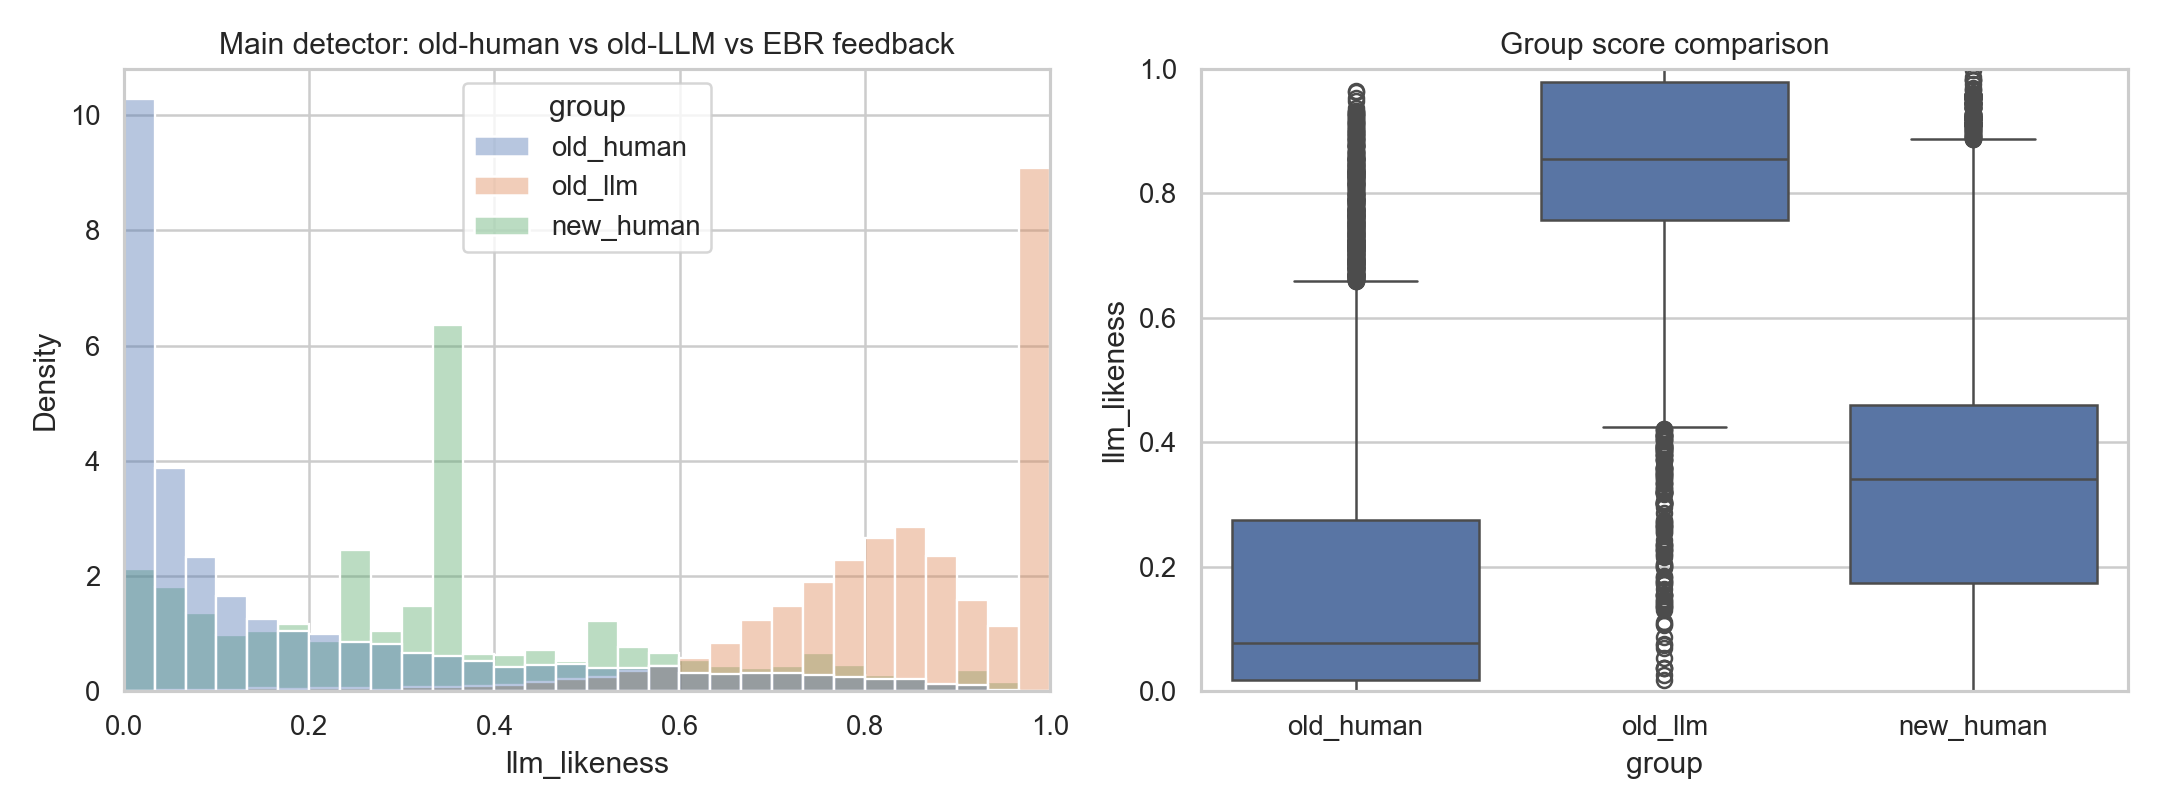

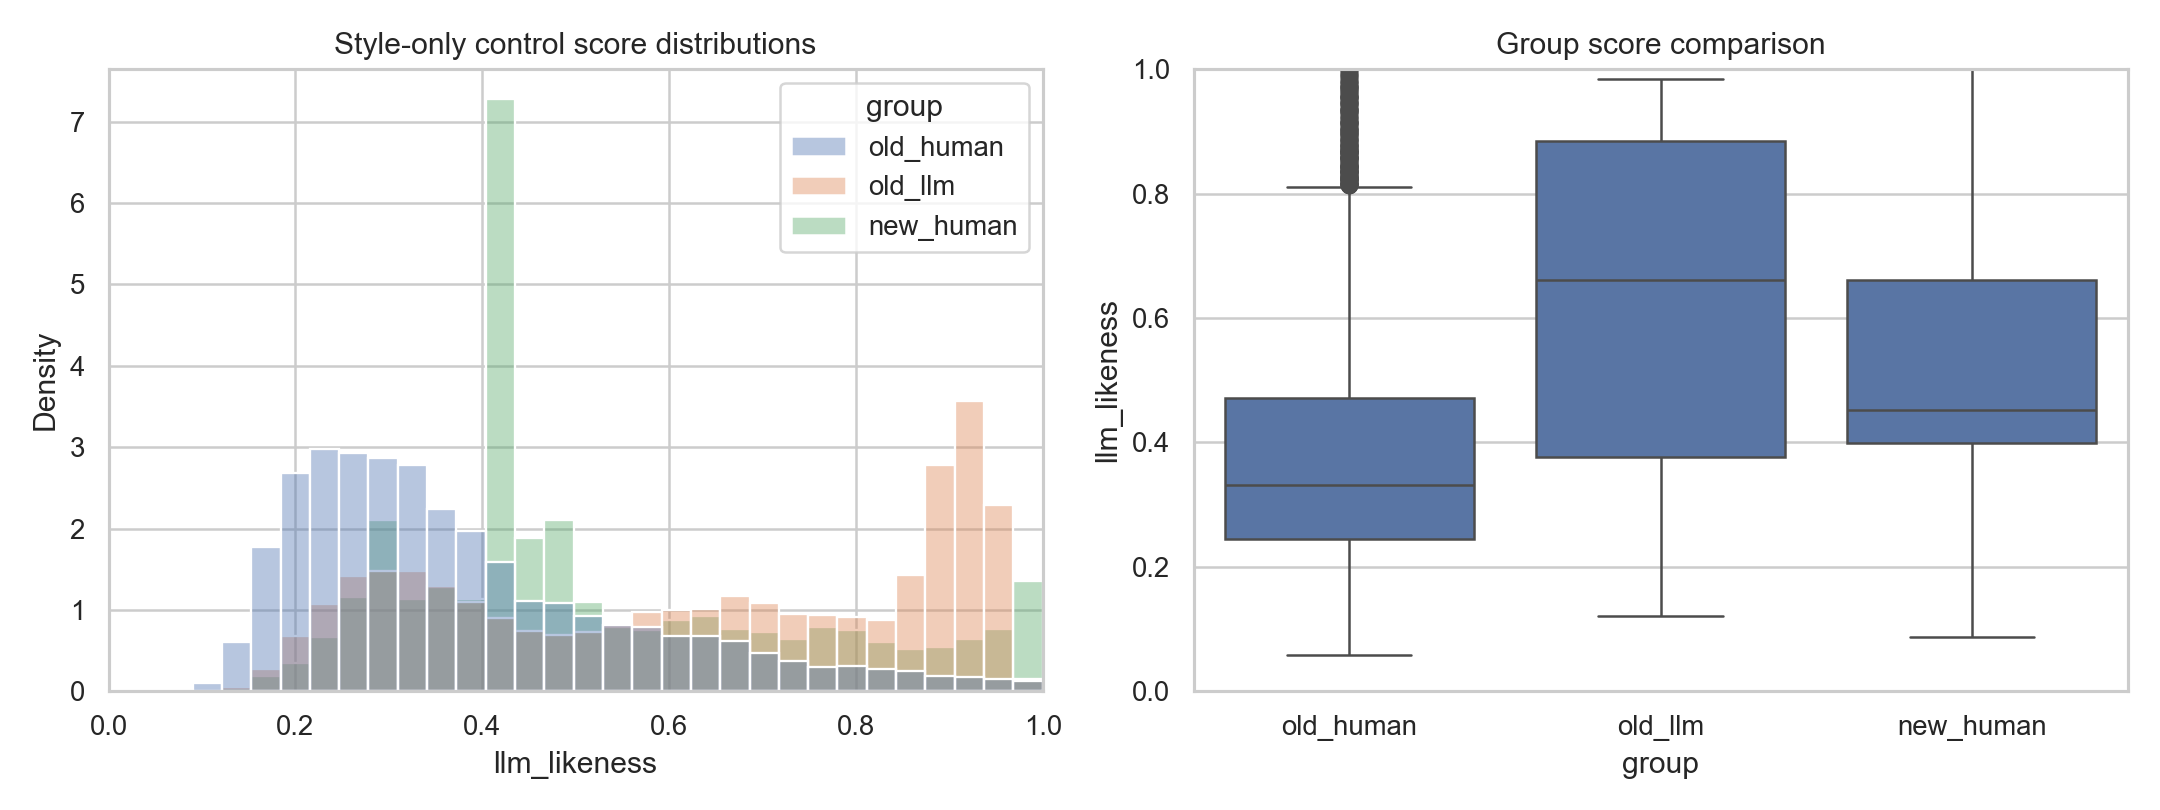

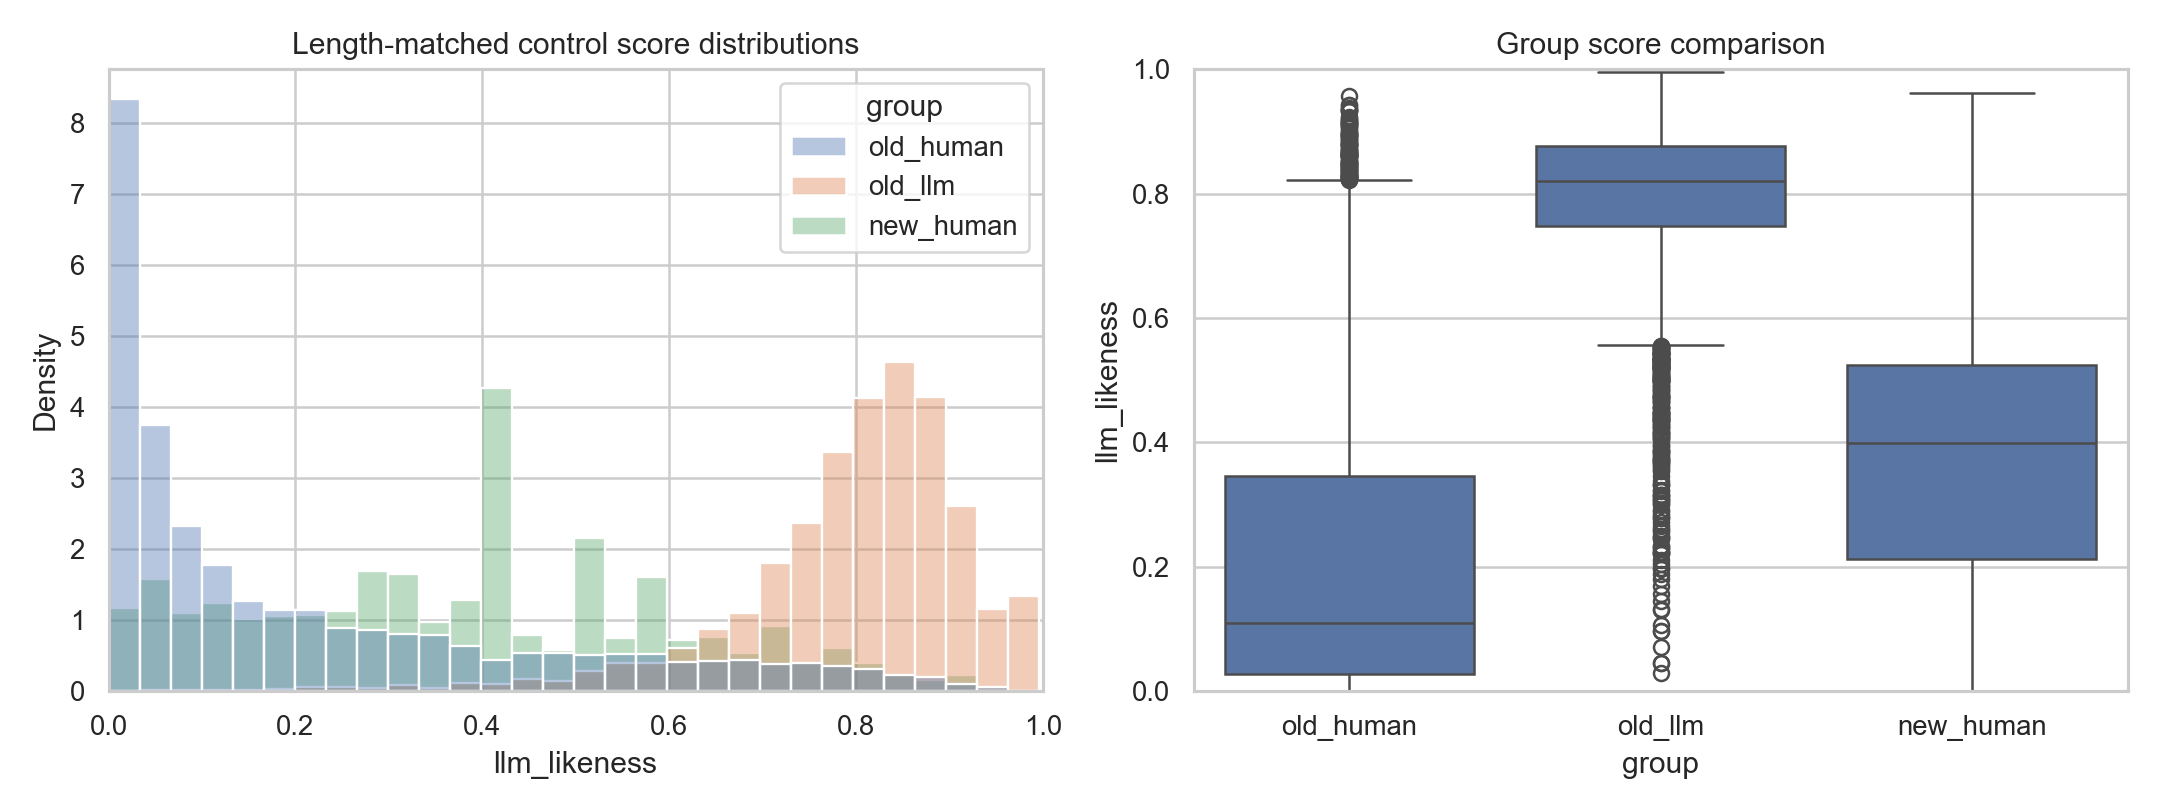

In [97]:
from IPython.display import Image, display

project_root = Path.cwd() if (Path.cwd() / 'outputs').exists() else Path.cwd().parent
fig_paths = [
    project_root / 'outputs' / 'figures' / 'llm_likeness_distributions_main.png',
    project_root / 'outputs' / 'figures' / 'llm_likeness_distributions_style_only.png',
    project_root / 'outputs' / 'figures' / 'llm_likeness_distributions_length_matched.png',
]

for fp in fig_paths:
    if fp.exists():
        display(Image(filename=str(fp)))
    else:
        print(f'Figure not found yet: {fp}')



### Interpretation Of Distribution Figures
In this section, we interpret the saved distribution plots and connect them to the summary tables produced by the notebook.

Across the plots, the same broad ordering appears: **old_human < new_human < old_llm** on average LLM-likeness scores.

Main detector interpretation:
- `old_human` mean score is **0.184**.
- `new_human` (EBR) mean score is **0.338**, higher than old_human by about **0.154**.
- `old_llm` mean score is **0.8365**, clearly above both human groups.
- At threshold `>=0.8`, high-score rates are **old_human=2.30%**, **new_human=4.02%**, **old_llm=65.39%**.

Control checks:
- Style-only means: **old_human=0.381**, **new_human=0.523**, **old_llm=0.628**.
- Length-matched means: **old_human=0.218**, **new_human=0.383**, **old_llm=0.797**.
- Length-matched threshold rates: **old_human=2.88%**, **new_human=3.30%**, **old_llm=58.61%**.

Interpretation:
1. EBR feedback is consistently more LLM-like than the older e-SNLI human baseline.
2. EBR feedback still remains substantially less LLM-like than the synthetic e-SNLI LLM explanations.
3. The same ordering survives both the style-only control and the stricter length-matched control, which strengthens the case that the shift is not explained only by shallow style or length differences.
4. Because the main detector now suppresses the most obvious residual NLI scaffold tokens, this comparison is somewhat less tied to prompt-format artifacts than earlier versions of the notebook.

This evidence should be interpreted as **style similarity**, not as direct proof of annotator LLM usage.


### Preview Qualitative Audit Samples
In this section, we load the saved qualitative audit file from the reports output directory so high-scoring and low-scoring EBR examples can be reviewed manually.

Step-by-step:
1. Resolve the saved report-relative audit file path.
2. Load the qualitative audit CSV.
3. Display sample rows for manual interpretation.


In [98]:
project_root = Path.cwd() if (Path.cwd() / 'outputs').exists() else Path.cwd().parent
audit_path = project_root / 'outputs' / 'reports' / 'ebr_qualitative_audit.csv'

if audit_path.exists():
    audit = pd.read_csv(audit_path)
    audit.head(20)
else:
    print(f'Audit file not found yet: {audit_path}')



## Final Conclusion
In this final section, we synthesize the quantitative results, control analyses, and diagnostic checks into the main project conclusion.

In this notebook, we trained an explanation-style detector on older **e-SNLI** explanations by contrasting dataset-human explanations with synthetic LLM-generated explanations, then applied that detector to **EBR** human feedback to estimate how LLM-like newer explanation text appears.

This follows the intended project pipeline:
1. Build an old-human vs old-LLM detector on e-SNLI.
2. Run style-only and length-matched controls.
3. Compare score distributions across old-human, old-LLM, and new-human groups.

The main result should be interpreted relative to two references:
- **e-SNLI human explanations**: the older human baseline.
- **Synthetic e-SNLI LLM explanations**: the LLM-style reference.

The current distribution summaries show a consistent ordering in which EBR feedback scores above the older e-SNLI human baseline but below the synthetic old-LLM reference. In the main detector, mean scores are approximately **0.184** for old-human, **0.338** for EBR new-human, and **0.837** for old-LLM. That same ordering remains present under both the style-only and length-matched controls.

This notebook does **not** prove that annotators definitely used LLMs. Instead, it shows that newer human-written EBR feedback is more similar, under this detector, to synthetic LLM explanations than older e-SNLI human explanations are. That pattern may reflect direct LLM assistance, broader writing-norm shifts, or other dataset or task differences.

The additional robustness checks strengthen this interpretation by showing that the strong old-human vs old-LLM separation persists across repeated smaller, stratified, pair-disjoint splits, with mean F1 rising from about **0.880** at 500 train pairs to about **0.930** at 8000 train pairs. At the same time, the shortcut diagnostics show that while direct pair leakage is absent and synthetic exact-text overlap across train and eval is absent, nonzero exact text overlap still exists in the human train/eval splits and some residual synthetic regularities remain.

Overall, the project shows that a simple explanation-style detector can study LLM-likeness shift across datasets and time periods. The key takeaway is a **measurable stylistic shift** toward the synthetic-LLM reference, but one that should still be interpreted with caution because the baseline detector remains a project-specific proxy rather than a definitive test of general human-versus-LLM writing.
